<a href="https://colab.research.google.com/github/tashir0605/Cocepts-And-Practice/blob/main/LLM%20Finetuning/transfer_learning_finetuning_in_deep_learning_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
zip_ref = zipfile.ZipFile('/content/data.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

FileNotFoundError: [Errno 2] No such file or directory: '/content/data.zip'

In [ ]:
import os
import tensorflow
import numpy as np
from keras import Sequential
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import Model
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image

# Part-1

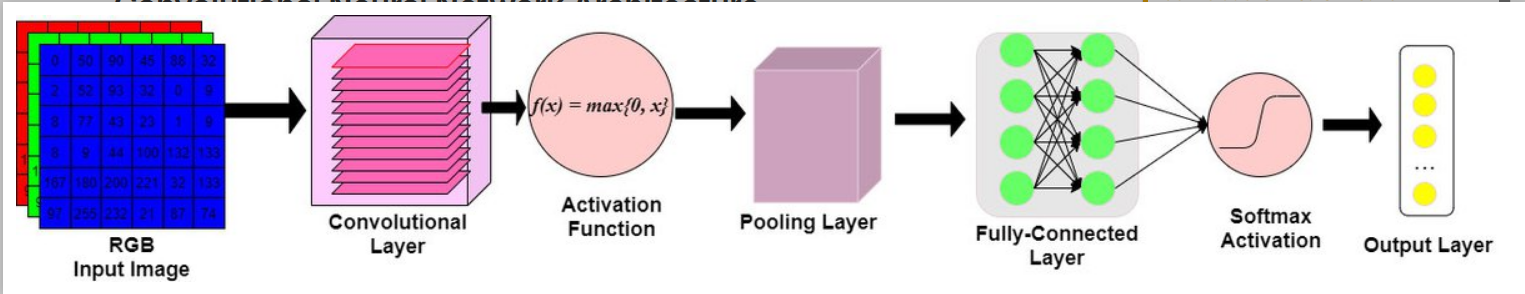

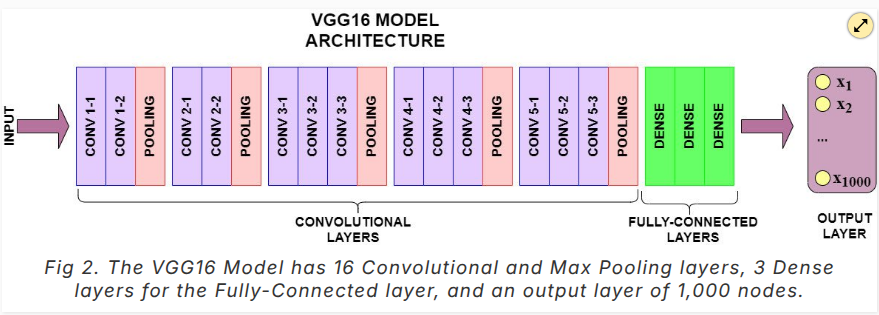

In [ ]:
# Load the VGG16 model pre-trained on the 'ImageNet' dataset
vgg = VGG16(
    weights='imagenet',      # Use weights from pre-training on ImageNet
    include_top = True,      # Include the fully-connected output layers at the top of the network of VGG16 Architecture
    input_shape=(224, 224, 3) # Define the input shape: 224x224 pixels with 3 color channels (RGB)
)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


 **Pooling layers are untrainable**

In [ ]:
for layer in vgg.layers:
    print(f"{layer.name:<20} | Type: {type(layer).__name__:<20} | Trainable: {layer.trainable}")

input_layer          | Type: InputLayer           | Trainable: True
block1_conv1         | Type: Conv2D               | Trainable: True
block1_conv2         | Type: Conv2D               | Trainable: True
block1_pool          | Type: MaxPooling2D         | Trainable: True
block2_conv1         | Type: Conv2D               | Trainable: True
block2_conv2         | Type: Conv2D               | Trainable: True
block2_pool          | Type: MaxPooling2D         | Trainable: True
block3_conv1         | Type: Conv2D               | Trainable: True
block3_conv2         | Type: Conv2D               | Trainable: True
block3_conv3         | Type: Conv2D               | Trainable: True
block3_pool          | Type: MaxPooling2D         | Trainable: True
block4_conv1         | Type: Conv2D               | Trainable: True
block4_conv2         | Type: Conv2D               | Trainable: True
block4_conv3         | Type: Conv2D               | Trainable: True
block4_pool          | Type: MaxPooling2D       

In [ ]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()
model.add(vgg)
model.add(Dense(1,activation='sigmoid'))

In [ ]:
# It is from Functional API
# x = vgg.layers[-2].output
# output = Dense(1, activation='sigmoid')(x)
# model = Model(inputs=vgg.input, outputs=output)
# model.summary()

In [ ]:
# SUMMARY: This block creates training and validation dataset generators from local directories.
# It automatically labels images based on folder names and resizes them for the VGG16 model.

# Create the training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/train', # Path to the folder containing subfolders of training images
    labels='inferred',                 # Automatically generate labels from the subfolder names
    label_mode = 'int',                # Encode labels as integers (e.g., 0, 1, 2...)
    batch_size=32,                     # Group images into batches of 32 for memory efficiency
    image_size=(224, 224)              # Resize all images to 224x224 to match the expected model input
)

# Create the validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/val',   # Path to the folder containing subfolders of validation images
    labels='inferred',                 # Automatically generate labels from the subfolder names
    label_mode = 'int',                # Encode labels as integers
    batch_size=32,                     # Keep batch size consistent with training
    image_size=(224, 224)              # Keep image size consistent with training
)

Found 838 files belonging to 2 classes.
Found 390 files belonging to 2 classes.


This function, called 'process', is a preprocessing step for your images. It takes an image and its label as input, then divides the image's pixel values by 255. Since pixels range from 0 to 255, this scales them to a range between 0 and 1 (normalization), which helps the neural network learn faster and more effectively. It also uses 'tensorflow.cast' to ensure the data is in the 'float32' format required for training.

In [ ]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

In [ ]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_ds,epochs=5,validation_data=validation_ds,verbose=1)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.4895 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 538ms/step - accuracy: 0.5216 - loss: 0.6925 - val_accuracy: 0.5051 - val_loss: 0.6917
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 545ms/step - accuracy: 0.5220 - loss: 0.6914 - val_accuracy: 0.5513 - val_loss: 0.6908
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 539ms/step - accuracy: 0.5294 - loss: 0.6903 - val_accuracy: 0.6487 - val_loss: 0.6895
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 534ms/step - accuracy: 0.5973 - loss: 0.6890 - val_accuracy: 0.6205 - val_loss: 0.6880


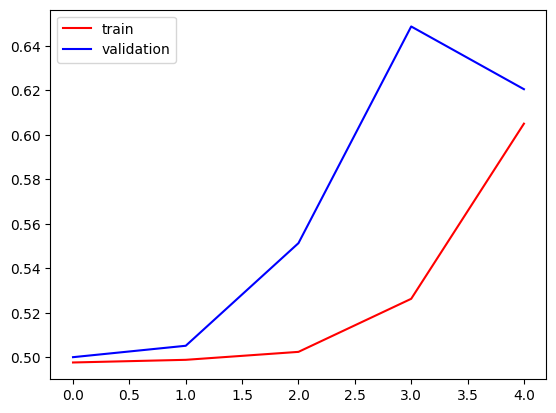

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
# Path to one test image
img_path = '/content/data/test/dog.3533.jpg'

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

In [ ]:
# Predict
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [ ]:
# Interpret result
label = "Dog 🐶" if prediction[0][0] > 0.5 else "Cat 🐱"
confidence = prediction[0][0]

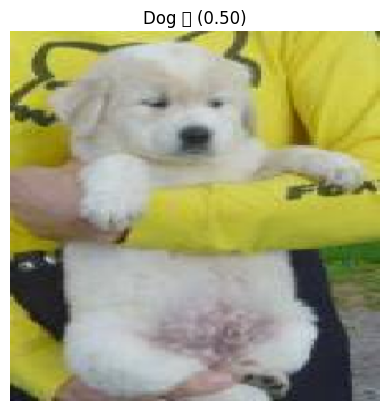

In [ ]:
# Show result
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis('off')
plt.show()

## Part-2

In [ ]:
vgg_conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(224, 224, 3)
)

In [ ]:
for layer in vgg_conv_base.layers:
    print(f"{layer.name:<20} | Type: {type(layer).__name__:<20} | Trainable: {layer.trainable}")

input_layer_4        | Type: InputLayer           | Trainable: True
block1_conv1         | Type: Conv2D               | Trainable: True
block1_conv2         | Type: Conv2D               | Trainable: True
block1_pool          | Type: MaxPooling2D         | Trainable: True
block2_conv1         | Type: Conv2D               | Trainable: True
block2_conv2         | Type: Conv2D               | Trainable: True
block2_pool          | Type: MaxPooling2D         | Trainable: True
block3_conv1         | Type: Conv2D               | Trainable: True
block3_conv2         | Type: Conv2D               | Trainable: True
block3_conv3         | Type: Conv2D               | Trainable: True
block3_pool          | Type: MaxPooling2D         | Trainable: True
block4_conv1         | Type: Conv2D               | Trainable: True
block4_conv2         | Type: Conv2D               | Trainable: True
block4_conv3         | Type: Conv2D               | Trainable: True
block4_pool          | Type: MaxPooling2D       

In [ ]:
vgg_conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Construct a new Sequential model using VGG16 as a feature extractor (Convolutional Base)
model = Sequential()
model.add(vgg_conv_base) # Add the VGG16 base (with include_top=False)
model.add(Flatten())     # Flatten the 3D feature maps to 1D for the dense layers
model.add(Dense(256,activation='relu')) # Add a fully connected layer with 256 neurons and ReLU activation
model.add(Dense(1,activation='sigmoid')) # Final output layer for binary classification (0 or 1)

In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224, 224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/val',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224, 224)
)

Found 838 files belonging to 2 classes.
Found 390 files belonging to 2 classes.


In [ ]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

In [ ]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_ds,epochs=5,validation_data=validation_ds,verbose=1)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 667ms/step - accuracy: 0.6493 - loss: 0.6194 - val_accuracy: 0.8538 - val_loss: 0.3461
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 531ms/step - accuracy: 0.9314 - loss: 0.2166 - val_accuracy: 0.9462 - val_loss: 0.1786
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 524ms/step - accuracy: 0.9704 - loss: 0.1105 - val_accuracy: 0.9077 - val_loss: 0.2401
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 524ms/step - accuracy: 0.9525 - loss: 0.0962 - val_accuracy: 0.9308 - val_loss: 0.1901
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 527ms/step - accuracy: 0.9986 - loss: 0.0213 - val_accuracy: 0.9564 - val_loss: 0.1299


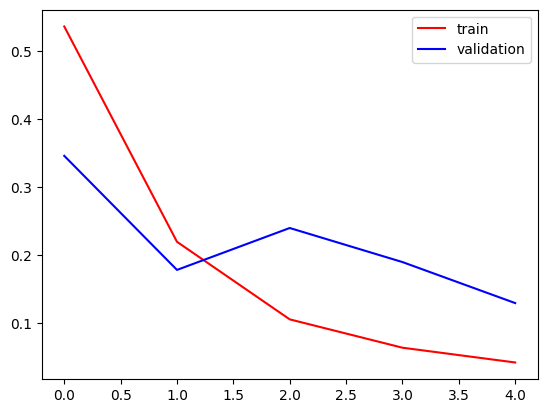

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step


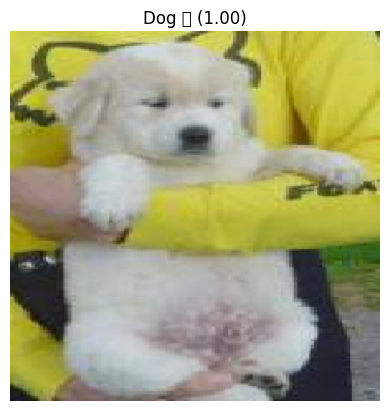

In [ ]:
# Path to one test image
img_path = '/content/data/test/dog.3533.jpg'

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0
# Predict
prediction = model.predict(img_array)

# Interpret result
label = "Dog 🐶" if prediction[0][0] > 0.5 else "Cat 🐱"
confidence = prediction[0][0]

# Show result
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis('off')
plt.show()

# Part-3

In [ ]:
vgg_conv_base.layers

[<InputLayer name=input_layer_4, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [ ]:
vgg_conv_base.trainable = True

In [ ]:
vgg_conv_base.trainable

True

In [ ]:
vgg_conv_base.trainable = False

In [ ]:
vgg_conv_base.trainable

False

In [ ]:
set_trainable = False

In [ ]:
# Selective Fine-tuning: Freeze early layers and unfreeze the last block
for layer in vgg_conv_base.layers:
  if layer.name == 'block5_conv1': # Once we reach the 5th convolutional block...
    set_trainable = True           # ...start marking layers as trainable
  if set_trainable:
    layer.trainable = True         # This layer will be updated during training
  else:
    layer.trainable = False        # These weights remain frozen to preserve pre-trained features

In [ ]:
for layer in vgg_conv_base.layers:
    print(f"{layer.name:<20} | Type: {type(layer).__name__:<20} | Trainable: {layer.trainable}")

input_layer_4        | Type: InputLayer           | Trainable: False
block1_conv1         | Type: Conv2D               | Trainable: False
block1_conv2         | Type: Conv2D               | Trainable: False
block1_pool          | Type: MaxPooling2D         | Trainable: False
block2_conv1         | Type: Conv2D               | Trainable: False
block2_conv2         | Type: Conv2D               | Trainable: False
block2_pool          | Type: MaxPooling2D         | Trainable: False
block3_conv1         | Type: Conv2D               | Trainable: False
block3_conv2         | Type: Conv2D               | Trainable: False
block3_conv3         | Type: Conv2D               | Trainable: False
block3_pool          | Type: MaxPooling2D         | Trainable: False
block4_conv1         | Type: Conv2D               | Trainable: False
block4_conv2         | Type: Conv2D               | Trainable: False
block4_conv3         | Type: Conv2D               | Trainable: False
block4_pool          | Type: MaxPo

In [ ]:
model = Sequential()
model.add(vgg_conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224, 224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/data/val',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224, 224)
)

Found 838 files belonging to 2 classes.
Found 390 files belonging to 2 classes.


In [ ]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

In [ ]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_ds,epochs=5,validation_data=validation_ds,verbose=1)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 384ms/step - accuracy: 0.7708 - loss: 0.4971 - val_accuracy: 0.9436 - val_loss: 0.1658
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 276ms/step - accuracy: 0.9709 - loss: 0.1007 - val_accuracy: 0.9359 - val_loss: 0.1489
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.9916 - loss: 0.0386 - val_accuracy: 0.9359 - val_loss: 0.1487
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - accuracy: 1.0000 - loss: 0.0188 - val_accuracy: 0.9436 - val_loss: 0.1374
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9410 - val_loss: 0.1623


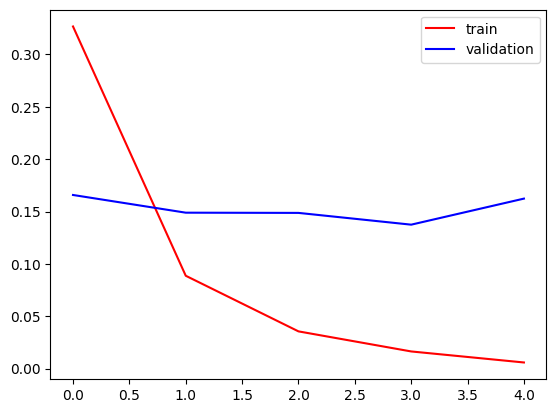

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step


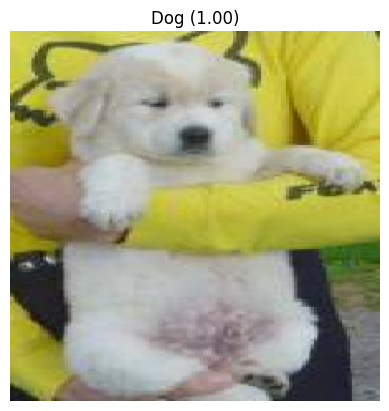

In [ ]:
# Path to one test image
img_path = '/content/data/test/dog.3533.jpg'

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0
# Predict
prediction = model.predict(img_array)

# Interpret result
label = "Dog" if prediction[0][0] > 0.5 else "Cat"
confidence = prediction[0][0]

# Show result
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis('off')
plt.show()

# Lets understand Transfer Learning and Finetuning with BERT now.

In [ ]:
!pip install datasets

In [ ]:
from transformers import BertTokenizer
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from transformers import TrainingArguments, Trainer, BertForSequenceClassification
from transformers import BertModel


In [ ]:
from datasets import load_dataset, ClassLabel

# Load original dataset
dataset = load_dataset("emotion", split="train")

# Step 1: Filter only desired labels (0=sadness, 1=joy, 3=anger)
dataset = dataset.filter(lambda x: x['label'] in [0, 1, 3])

# Step 2: Remap labels to 0,1,2
label_map = {0: 0, 1: 1, 3: 2}
dataset = dataset.map(lambda x: {"label": label_map[x["label"]]})

# Step 3: Properly update label class names using ClassLabel
new_label_feature = ClassLabel(num_classes=3, names=["sadness", "joy", "anger"])
dataset = dataset.cast_column("label", new_label_feature)

# Verify
print(dataset.features["label"].names)


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12187 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/12187 [00:00<?, ? examples/s]

['sadness', 'joy', 'anger']


In [ ]:
dataset = dataset.train_test_split(test_size=0.2)

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9749
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2438
    })
})

In [ ]:
train_texts = dataset['train']['text']

In [ ]:
print(train_texts)

['i dont want to make him into someone i need or feel helpless without him', 'i feel that im fine without him', 'i talk a lot about feeling isolated', 'im feeling pretty discouraged this morning', 'i have been plagued throughout my life with this uncanny feeling of disappointment that it isn t enough that i am doomed to fail and others will delight in it with an i told you so', 'i have written but you feel the need to point out that someone somewhere could be offended if they were to read my words out of context knowing nothing about me and after having a really bad day do not bother to inform me of this', 'i am feeling really quite disheartened', 'i feel incredibly disappointed in myself', 'i don t feel any safe', 'i think that for as much as i could feel myself trying to hide it my face must have betrayed the fact that i was none too pleased about being woken at such ungodly hour in the afternoon', 'i want to feel like a nurtured respected protected equal', 'i would feel the speech i

In [ ]:
print(len(train_texts))

9749


In [ ]:
train_labels = dataset['train']['label']

In [ ]:
train_labels

[0,
 1,
 0,
 0,
 0,
 2,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 2,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 2,
 1,
 1,
 2,
 2,
 0,
 1,
 1,
 1,
 2,
 2,
 1,
 0,
 1,
 2,
 2,
 0,
 2,
 0,
 1,
 2,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 2,
 0,
 0,
 0,
 1,
 2,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 2,
 2,
 0,
 2,
 0,
 2,
 0,
 1,
 0,
 1,
 0,
 0,
 2,
 1,
 1,
 1,
 2,
 0,
 2,
 0,
 0,
 1,
 2,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 2,
 2,
 0,
 1,
 2,
 2,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 2,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 2,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 2,
 2,
 1,
 0,
 0,
 2,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 2,
 2,
 0,
 0,
 1,
 1,
 2,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 2,
 1,
 2,
 1,
 1,
 2,
 1,
 2,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 2,
 1,
 1,
 0,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 0,
 1,
 0,


In [ ]:
print(len(train_labels))

9749


In [ ]:
val_texts = dataset['test']['text']
val_labels = dataset['test']['label']

In [ ]:
print(len(val_texts))
print(len(val_labels))

2438
2438


## we can finetune the bert for Text Classification, Named Entity Recognition (NER), Question Answering

## Translation,Text Summarization(BART, T5)
#### bert is not well suited for above task

In [ ]:
# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, return_tensors='pt')

In [ ]:
dataset = dataset.map(lambda x: tokenizer(x['text'], padding="max_length", truncation=True), batched=True)

Map:   0%|          | 0/9749 [00:00<?, ? examples/s]

Map:   0%|          | 0/2438 [00:00<?, ? examples/s]

In [ ]:
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

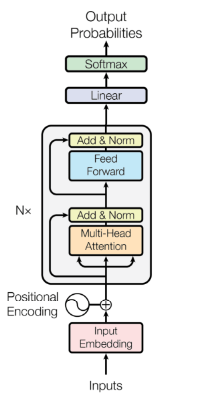

In [ ]:
# Load pre-trained model with new output head
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased"
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


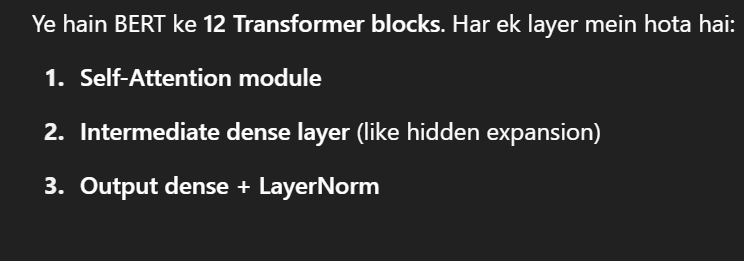

In [ ]:
for name, param in model.named_parameters():
    print(f"{name:50} | Shape: {tuple(param.shape)} | Trainable: {param.requires_grad}")

bert.embeddings.word_embeddings.weight             | Shape: (30522, 768) | Trainable: True
bert.embeddings.position_embeddings.weight         | Shape: (512, 768) | Trainable: True
bert.embeddings.token_type_embeddings.weight       | Shape: (2, 768) | Trainable: True
bert.embeddings.LayerNorm.weight                   | Shape: (768,) | Trainable: True
bert.embeddings.LayerNorm.bias                     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.query.weight   | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.query.bias     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.key.weight     | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.key.bias       | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.value.weight   | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.value.bias     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.output.den

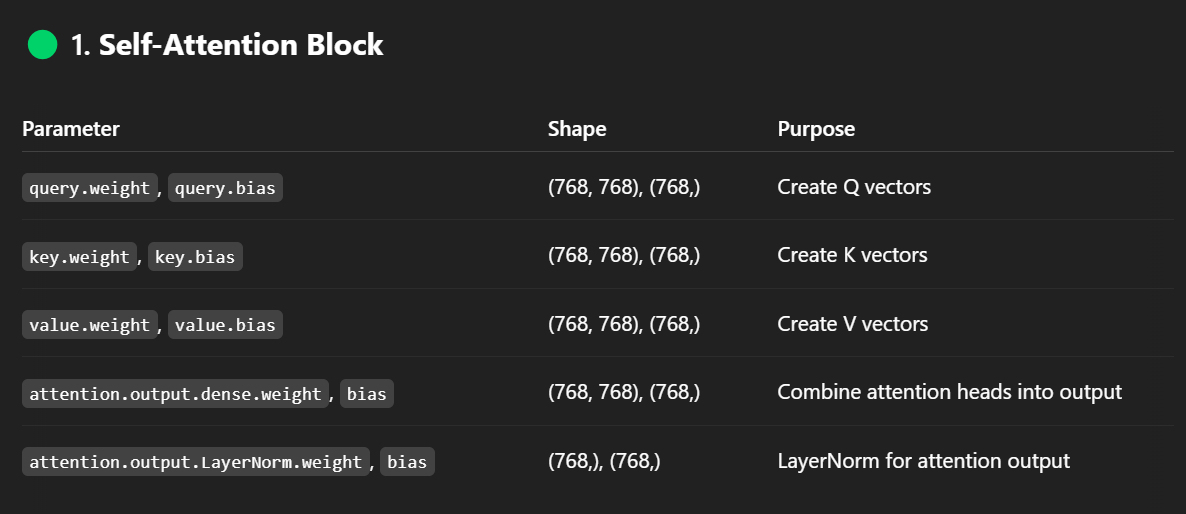

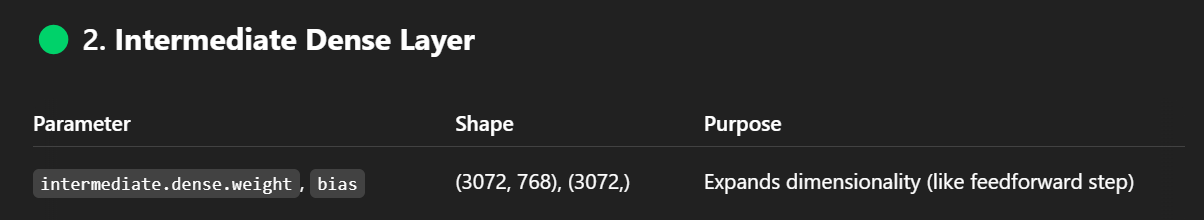

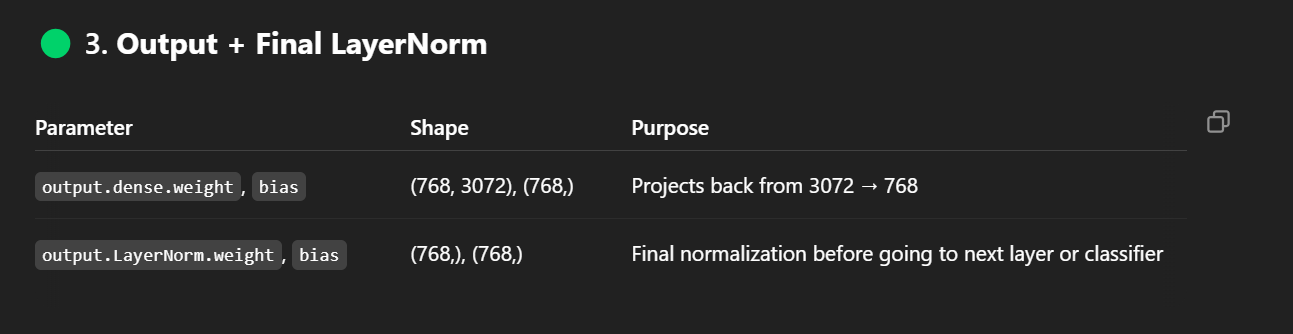

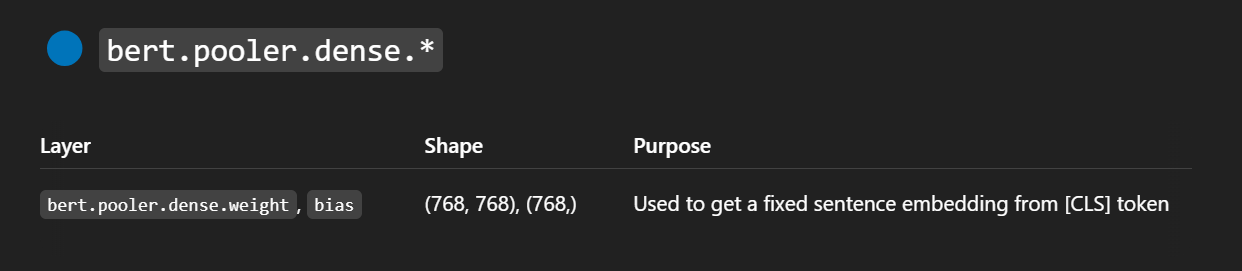

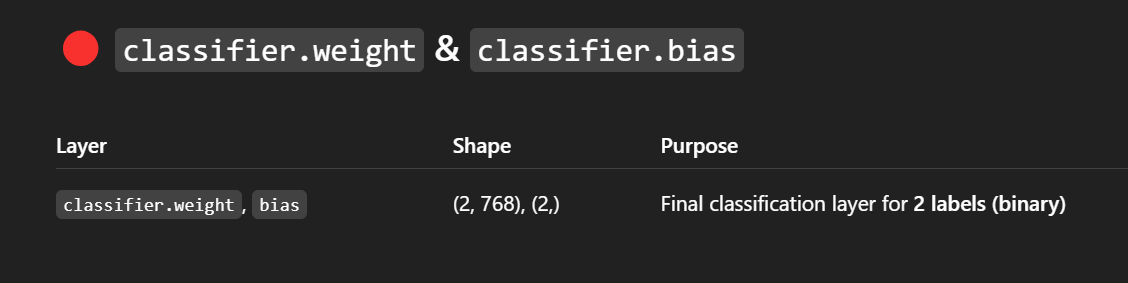

In [ ]:
model_for_cls = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3  # For binary classification
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
for name, param in model_for_cls.named_parameters():
    print(f"{name:50} | Shape: {tuple(param.shape)} | Trainable: {param.requires_grad}")

bert.embeddings.word_embeddings.weight             | Shape: (30522, 768) | Trainable: True
bert.embeddings.position_embeddings.weight         | Shape: (512, 768) | Trainable: True
bert.embeddings.token_type_embeddings.weight       | Shape: (2, 768) | Trainable: True
bert.embeddings.LayerNorm.weight                   | Shape: (768,) | Trainable: True
bert.embeddings.LayerNorm.bias                     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.query.weight   | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.query.bias     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.key.weight     | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.key.bias       | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.self.value.weight   | Shape: (768, 768) | Trainable: True
bert.encoder.layer.0.attention.self.value.bias     | Shape: (768,) | Trainable: True
bert.encoder.layer.0.attention.output.den

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 109483778


In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Trainable parameters: 109483778


In [ ]:
print(model_for_cls.bert.embeddings)

BertEmbeddings(
  (word_embeddings): Embedding(30522, 768, padding_idx=0)
  (position_embeddings): Embedding(512, 768)
  (token_type_embeddings): Embedding(2, 768)
  (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [ ]:
print(model_for_cls.bert.encoder.layer[11])

BertLayer(
  (attention): BertAttention(
    (self): BertSdpaSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


In [ ]:
print(model_for_cls.classifier)

Linear(in_features=768, out_features=3, bias=True)


In [ ]:
print(model_for_cls.config)  # Model config: hidden size, num labels, dropout, etc.

BertConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.51.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [ ]:
# Training args
training_args = TrainingArguments(
    output_dir="./bert_output_1",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs",
     report_to="none"
)

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
# Trainer
trainer = Trainer(
    model=model_for_cls,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.389500
1000,0.166700
1500,0.095900


KeyboardInterrupt: 

# unfreeze couple of last layer then train it


In [ ]:
from transformers import BertModel, BertTokenizer, PreTrainedModel, Trainer, TrainingArguments, BertConfig
from transformers.modeling_outputs import SequenceClassifierOutput

In [ ]:
bert = BertModel.from_pretrained("bert-base-uncased")

In [ ]:
for param in bert.parameters():
  #print(param)
  param.requires_grad = False

In [ ]:
bert.encoder

BertEncoder(
  (layer): ModuleList(
    (0-11): 12 x BertLayer(
      (attention): BertAttention(
        (self): BertSdpaSelfAttention(
          (query): Linear(in_features=768, out_features=768, bias=True)
          (key): Linear(in_features=768, out_features=768, bias=True)
          (value): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (output): BertSelfOutput(
          (dense): Linear(in_features=768, out_features=768, bias=True)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
      (intermediate): BertIntermediate(
        (dense): Linear(in_features=768, out_features=3072, bias=True)
        (intermediate_act_fn): GELUActivation()
      )
      (output): BertOutput(
        (dense): Linear(in_features=3072, out_features=768, bias=True)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=T

In [ ]:
bert.encoder.layer

ModuleList(
  (0-11): 12 x BertLayer(
    (attention): BertAttention(
      (self): BertSdpaSelfAttention(
        (query): Linear(in_features=768, out_features=768, bias=True)
        (key): Linear(in_features=768, out_features=768, bias=True)
        (value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (output): BertSelfOutput(
        (dense): Linear(in_features=768, out_features=768, bias=True)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (intermediate): BertIntermediate(
      (dense): Linear(in_features=768, out_features=3072, bias=True)
      (intermediate_act_fn): GELUActivation()
    )
    (output): BertOutput(
      (dense): Linear(in_features=3072, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
)

In [ ]:
# for layer in bert.encoder.layer[-2:]
for layer in bert.encoder.layer:
  print(layer)

BertLayer(
  (attention): BertAttention(
    (self): BertSdpaSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)
BertLayer(
  (attention): BertAttention(
    (self): BertSdpaSelfAttention(
 

In [ ]:
for layer in bert.encoder.layer[-2:]:
  print(layer)

BertLayer(
  (attention): BertAttention(
    (self): BertSdpaSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)
BertLayer(
  (attention): BertAttention(
    (self): BertSdpaSelfAttention(
 

In [ ]:
for layer in bert.encoder.layer[-2:]:
  for param in layer.parameters():
    param.requires_grad = True
    #print(param)

In [ ]:
# Define a custom PyTorch class for Multi-Class Sentiment Analysis using BERT
class BertMultiClassClassifier(PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        # Load the base BERT model (encoder only)
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        # Add a custom linear classifier head mapping BERT's 768 hidden features to 3 classes
        self.classifier = nn.Linear(config.hidden_size, 3)

        # Step 1: Freeze all BERT parameters to start with
        for param in self.bert.parameters():
            param.requires_grad = False

        # Step 2: Unfreeze the last 2 encoder layers for fine-tuning to our specific text
        for layer in self.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Step 3: Unfreeze the pooler and the final classifier layer
        for param in self.bert.pooler.parameters():
            param.requires_grad = True

        for param in self.classifier.parameters():
            param.requires_grad = True

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        # Pass inputs through BERT to get hidden states
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Extract the [CLS] token representation (pooled output) for classification
        pooled_output = outputs.pooler_output
        # Get raw prediction scores (logits)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            # Calculate CrossEntropyLoss if labels are provided during training
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

In [ ]:
config = BertConfig.from_pretrained("bert-base-uncased", num_labels=3)

In [ ]:
model = BertMultiClassClassifier(config)

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_last2layers_finetune",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy="no",
    report_to="none",  # Disable wandb etc.
    logging_dir="./logs"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)

trainer.train()

Step,Training Loss
500,0.579600
1000,0.345100


KeyboardInterrupt: 

In [ ]:
label_names = ["sadness", "joy", "anger"]

def predict_text(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=128)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()
        confidence = torch.softmax(logits, dim=1)[0][predicted_class].item()

    label_name = label_names[predicted_class]
    print(f"Text: {text}")
    print(f"Prediction: {label_name} (Confidence: {confidence:.2f})")
    return predicted_class, confidence

In [ ]:
predict_text("I'm feeling really happy today!", model, tokenizer)
predict_text("I just want to cry and sleep.", model, tokenizer)